# Стохастический анализ, зима 2026

# Домашнее задание 3: чистовое решение

В ноутбуке собраны решения теоретических листков `HW3_1.pdf`, `HW3_2.pdf` и программной части про численные схемы для SDE, диффузию Ланжевена и ULA-рисование.


## Листок 1. Процессы Леви и интеграл Ито

### Упражнение 1.1

Пусть $P_t=\sum_{k=1}^{N_t}J_k$ - составной пуассоновский процесс, $N_t$ имеет интенсивность $\lambda$, а $J_k\sim\operatorname{Exp}(\mu)$. Для
$$
X_t=P_t+3t
$$
мера Леви равна
$$
\nu(dx)=\lambda\mu e^{-\mu x}\mathbf 1_{\{x>0\}}\,dx.
$$
Гауссовской части нет. Так как скачки имеют конечную интенсивность и конечное среднее, в представлении конечной вариации можно записать тройку как
$$
\boxed{(d,0,\nu),\qquad d=3.}
$$

Если использовать стандартную лево-хинчинскую конвенцию с компенсатором $x\mathbf 1_{\{|x|\le1\}}$, то дрейфовый параметр меняется:
$$
\gamma
=3+\int_0^1x\,\nu(dx)
=3+\lambda\int_0^1x\mu e^{-\mu x}\,dx
=3+\frac{\lambda}{\mu}\bigl(1-e^{-\mu}(1+\mu)\bigr).
$$
Обе записи описывают один и тот же процесс, но относятся к разным конвенциям записи тройки Леви.

### Упражнение 1.2

Пусть $f(\omega,t)$ имеет непрерывные траектории на $[0,T]$. Для фиксированного $\omega$ это обычная непрерывная функция на компакте, поэтому любые римановы суммы с точками внутри отрезков сходятся к
$$
I(\omega)=\int_0^T f(\omega,t)\,dt.
$$
Для сумм из условия, включая
$$
I_n^\alpha=\sum_i f\bigl(\alpha t_i+(1-\alpha)t_{i+1},\omega\bigr)\Delta t_i,
$$
имеем детерминированную оценку
$$
\left|I_n^\alpha-I\right|\le T\,\omega_f(|\Delta_n|,\omega),
$$
где $\omega_f(\delta,\omega)$ - модуль непрерывности траектории. Правая часть стремится к нулю почти наверное.

Важная оговорка после ревью: из условия $\mathbb E M<\infty$, где
$$
M=\sup_{t\in[0,T]}|f(t,\omega)|,
$$
следует сходимость в $L^1$, но для буквальной сходимости в $L^2$ этого недостаточно. Контрпример: $f(t,\omega)=Y(\omega)$, где $\mathbb E|Y|<\infty$, но $\mathbb E Y^2=\infty$. Тогда все суммы равны $TY$ и не являются $L^2$-случайными величинами.

Если добавить естественное для $L^2$ усиление $M\in L^2$, то доказательство завершается теоремой Лебега о мажорированной сходимости:
$$
|I_n^\alpha-I|^2\le 4T^2M^2,
$$
и правая часть интегрируема. Значит, при $M\in L^2$
$$
\boxed{I_n,\ J_n,\ I_n^\alpha\to \int_0^T f(t,\omega)\,dt\quad\text{в }L^2.}
$$
При исходной формулировке без $M\in L^2$ корректный гарантированный вывод - сходимость в $L^1$.

### Упражнение 1.3

Для интеграла Стратоновича
$$
\int_0^T W_t\circ dW_t
=\lim\sum_i \frac{W_{t_i}+W_{t_{i+1}}}{2}(W_{t_{i+1}}-W_{t_i}).
$$
Но
$$
\frac{W_{t_i}+W_{t_{i+1}}}{2}(W_{t_{i+1}}-W_{t_i})
=\frac12(W_{t_{i+1}}^2-W_{t_i}^2),
$$
поэтому
$$
\boxed{\int_0^T W_t\circ dW_t=\frac12W_T^2.}
$$
Для Ито:
$$
\int_0^T W_t\,dW_t=\frac12(W_T^2-T).
$$
Разница равна $T/2$.

Для детерминированного интегранта $t$ выбор середины не меняет предела:
$$
\boxed{\int_0^T t\circ dW_t=\int_0^Tt\,dW_t.}
$$
Также по интегрированию по частям
$$
\int_0^Tt\,dW_t=TW_T-\int_0^TW_t\,dt.
$$


### Упражнение 1.4

Рассматриваем интеграл как кратный интеграл Ито по симплексу
$$
0<t_1<t_2<t_3<T.
$$
Тогда
$$
I_3=\int_{0<t_1<t_2<t_3<T}dW_{t_1}dW_{t_2}dW_{t_3}.
$$
Для степеней Винеровского процесса верна формула Эрмита:
$$
W_T^3=6I_3+3TW_T.
$$
Следовательно,
$$
\boxed{I_3=\frac16(W_T^3-3TW_T).}
$$

Тонкость: если читать исходную вложенную запись буквально как последовательное интегрирование "изнутри наружу",
$$
\int_0^T\int_{t_1}^T\int_{t_2}^T dW_{t_3}\,dW_{t_2}\,dW_{t_1},
$$
то внутренние интегралы зависят от будущих приращений относительно внешнего времени, и это уже не обычный адаптированный интеграл Ито. Поэтому стандартная корректная трактовка здесь - именно кратный интеграл по детерминированному симплексу.

### Упражнение 1.5

Нужно показать, что при условии
$$
\mathbb E|f_t-f_s|^4\le K|t-s|^{2+\gamma}
$$
суммы с произвольными точками $t_i^*\in[t_i,t_{i+1}]$ сходятся к интегралу Ито. Предполагаем, что $f$ принадлежит классу интегрируемых по Ито процессов, то есть левые суммы Ито уже сходятся к $\int_0^T f(t)\,dW_t$.

Сравним произвольные суммы с левыми:
$$
S_\pi=\sum_i f(t_i^*)\Delta W_i-\sum_i f(t_i)\Delta W_i
=\sum_i (f(t_i^*)-f(t_i))\Delta W_i.
$$
Достаточно доказать, что $\|S_\pi\|_2\to0$. По неравенству Минковского в $L^2$:
$$
\|S_\pi\|_2
\le \sum_i \|(f(t_i^*)-f(t_i))\Delta W_i\|_2.
$$
Для каждого слагаемого используем Коши-Буняковского:
$$
\|(f(t_i^*)-f(t_i))\Delta W_i\|_2
\le
\left(\mathbb E|f(t_i^*)-f(t_i)|^4\right)^{1/4}
\left(\mathbb E(\Delta W_i)^4\right)^{1/4}.
$$
Так как $\mathbb E(\Delta W_i)^4=3(\Delta t_i)^2$, получаем
$$
\|(f(t_i^*)-f(t_i))\Delta W_i\|_2
\le C(\Delta t_i)^{1+\gamma/4}.
$$
Следовательно,
$$
\|S_\pi\|_2
\le C\sum_i(\Delta t_i)^{1+\gamma/4}
\le CT|\pi|^{\gamma/4}\to0.
$$
Значит,
$$
\boxed{
\sum_i f(t_i^*)\Delta W_i
\xrightarrow[L^2]{|\pi|\to0}
\int_0^T f(t)\,dW_t.
}
$$
Именно поэтому для достаточно регулярных траекторий выбор точки внутри отрезка не создаёт добавочной стратоновичевой поправки.

## Листок 2. Исчисление Ито

### Упражнение 2.1

Пусть
$$
X_t=tW_t+\int_0^t W_s\,dW_s.
$$
Тогда
$$
d(tW_t)=W_t\,dt+t\,dW_t,\qquad d\int_0^tW_s\,dW_s=W_t\,dW_t,
$$
поэтому
$$
dX_t=W_t\,dt+(t+W_t)\,dW_t.
$$

Для
$$
Y_t=t\cos X_t
$$
используем формулу Ито для $f(t,x)=t\cos x$:
$$
dY_t=\cos X_t\,dt-t\sin X_t\,dX_t-\frac12t\cos X_t\,(dX_t)^2.
$$
Так как
$$
(dX_t)^2=(t+W_t)^2dt,
$$
получаем
$$
\boxed{
dY_t=
\left[\cos X_t-tW_t\sin X_t-\frac12t(t+W_t)^2\cos X_t\right]dt
-t(t+W_t)\sin X_t\,dW_t.
}
$$


### Упражнение 2.2

В условии выражение читается как квадрат кубического корня:
$$
Z=
\left(\sqrt[3]{\int_0^tW_s^2\,dW_s+\int_0^tW_s\,ds}\right)^2.
$$
По формуле Ито
$$
d(W_t^3)=3W_t^2\,dW_t+3W_t\,dt.
$$
Значит,
$$
\int_0^tW_s^2\,dW_s+\int_0^tW_s\,ds=\frac13W_t^3.
$$
Тогда
$$
Z=\left(\sqrt[3]{W_t^3/3}\right)^2=\frac{W_t^2}{3^{2/3}}.
$$
Если $a=3^{-2/3}$, то $Z=aW_t^2$, где $W_t\sim N(0,t)$. Для $z>0$ плотность:
$$
\boxed{
f_Z(z)=\frac{1}{\sqrt{2\pi t a z}}\exp\left(-\frac{z}{2at}\right)
=\frac{3^{1/3}}{\sqrt{2\pi tz}}\exp\left(-\frac{3^{2/3}z}{2t}\right).
}
$$
В точке $0$ есть интегрируемая особенность плотности, атома в нуле нет.

### Упражнение 2.3

Пусть
$$
X_t=(W_t+t)e^{-W_t-t/2}.
$$
Рассмотрим $f(t,w)=(w+t)e^{-w-t/2}$. Производные:
$$
f_t=e^{-w-t/2}\left(1-\frac12(w+t)\right),
$$
$$
f_w=e^{-w-t/2}(1-w-t),
$$
$$
f_{ww}=e^{-w-t/2}(w+t-2).
$$
Дрейф в формуле Ито:
$$
f_t+\frac12f_{ww}=0.
$$
Следовательно,
$$
dX_t=e^{-W_t-t/2}(1-W_t-t)\,dW_t.
$$
Это локальный мартингал. Чтобы он был настоящим мартингалом на конечном горизонте, достаточно проверить интегрируемость стохастического интеграла:
$$
\mathbb E\int_0^T e^{-2W_s-s}(1-W_s-s)^2\,ds<\infty.
$$
Она следует из конечности экспоненциальных моментов нормального распределения с полиномиальным множителем. Поэтому
$$
\boxed{X_t\text{ - мартингал относительно винеровской фильтрации.}}
$$

### Упражнение 2.4

Пусть
$$
dX_t=v(t,\omega)\,dW_t.
$$

1. При стандартном условии предсказуемости и квадратичной интегрируемости $v$ процесс
$$
X_t=X_0+\int_0^t v(s,\omega)\,dW_s
$$
является мартингалом, если $X_0$ интегрируема и $\mathcal F_0$-измерима. Это ровно свойство интеграла Ито из лекции.

2. $X_t^2$ вообще не является мартингалом. Контрпример: $v\equiv1$, $X_0=0$, тогда $X_t=W_t$, а
$$
\mathbb E W_t^2=t
$$
зависит от $t$.

3. Если $v$ ограничен, то по формуле Ито
$$
dX_t^2=2X_t v(t,\omega)dW_t+v(t,\omega)^2dt.
$$
Значит,
$$
Y_t=X_t^2-\int_0^t|v(s,\omega)|^2ds
$$
имеет дифференциал
$$
dY_t=2X_tv(t,\omega)dW_t.
$$
При ограниченности $v$ этот стохастический интеграл имеет достаточную интегрируемость, поэтому
$$
\boxed{Y_t\text{ - мартингал}.}
$$

### Упражнение 2.5

Пусть для определенности $S\le T$ и $f\in V(0,T\vee S)$. Тогда
$$
\int_0^T f(t,\omega)dW_t=
\int_0^S f(t,\omega)dW_t+\int_S^T f(t,\omega)dW_t.
$$
Второй интеграл ортогонален первому: для простых адаптированных процессов это следует из независимости будущих приращений Винеровского процесса, а затем переносится на $V$ по $L^2$-замыканию. Поэтому по изометрии Ито
$$
\mathbb E\left[\int_0^S f\,dW\int_0^T f\,dW\right]
=\mathbb E\left[\left(\int_0^S f\,dW\right)^2\right]
=\mathbb E\int_0^S f(t,\omega)^2dt.
$$
В общем случае:
$$
\boxed{
\mathbb E\left[\int_0^S f\,dW\int_0^T f\,dW\right]
=\mathbb E\int_0^{S\wedge T}f(t,\omega)^2dt.
}
$$

### Упражнения 2.6-2.7, бонус

Для
$$
Y_t=\int_0^t e^{-s}\,dW_s
$$
процесс гауссовский с нулевым средним, потому что это $L^2$-предел линейных комбинаций гауссовских приращений. Ковариация:
$$
\operatorname{Cov}(Y_t,Y_s)=\int_0^{t\wedge s}e^{-2u}\,du
=\frac{1-e^{-2(t\wedge s)}}2.
$$
Значит, для любых $0\le t_1<\dots<t_n$ вектор $(Y_{t_1},\dots,Y_{t_n})$ имеет многомерное нормальное распределение с нулевым средним и матрицей
$$
\Sigma_{ij}=\frac{1-e^{-2(t_i\wedge t_j)}}2.
$$
Если матрица невырождена, плотность равна
$$
p(y)=\frac{1}{(2\pi)^{n/2}\det(\Sigma)^{1/2}}
\exp\left(-\frac12y^\top\Sigma^{-1}y\right).
$$

Для упражнения 2.7 я читаю $f$ как детерминированную функцию ограниченной вариации. Если $f$ случайная и зависит от $W$, универсального гауссовского ответа уже нет. При детерминированной $f$
$$
Y_t=\int_0^tf(s)dW_s
$$
снова гауссовский процесс с нулевым средним и ковариацией
$$
\operatorname{Cov}(Y_t,Y_s)=\int_0^{t\wedge s}f(u)^2du.
$$
Формально это следует из того, что интеграл Ито строится как $L^2$-предел сумм $\sum f(t_i)\Delta W_i$, то есть пределов гауссовских линейных комбинаций. Конечномерные распределения - многомерные нормальные с матрицей
$$
\Sigma_{ij}=\int_0^{t_i\wedge t_j}f(u)^2du,
$$
а плотность существует при невырожденной $\Sigma$ и имеет стандартный вид многомерной нормальной плотности.

## Программная часть. Численные схемы для SDE

### Как соотносятся сильный и слабый порядок

Если сильная ошибка порядка $k$:
$$
\mathbb E|Y_T^\Delta-X_T|\le C\Delta^k,
$$
то для любой липшицевой функции $f$ с константой $K$:
$$
|\mathbb Ef(Y_T^\Delta)-\mathbb Ef(X_T)|
\le \mathbb E|f(Y_T^\Delta)-f(X_T)|
\le K\mathbb E|Y_T^\Delta-X_T|
\le KC\Delta^k.
$$
Значит, на классе липшицевых функций слабый порядок не меньше сильного.

Ниже в эксперименте слабую ошибку считаем для функции $f(x)=x^5$:
$$
\hat\varepsilon_\Delta^{weak}
=\left|\frac1N\sum_{j=1}^N f(\hat X_{T,j}^{\Delta})
-\frac1N\sum_{j=1}^N f(X_{T,j})\right|.
$$
В шаблоне рядом с текстом про $f(x)=x^5$ формула записана как $\mathbb E(\hat X-X_T)$; это похоже на опечатку, поэтому код использует именно определение слабой ошибки через тестовую функцию.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
class SDESolver:
    def __init__(self, b, sigma):
        self.b = b
        self.sigma = sigma

    def step(self, x, t, tnext, tId=None, tNextId=None, ws=None):
        raise NotImplementedError

    def solve(self, x0, ts, tIds=None, returnLast=False, **kwargs):
        x0 = np.asarray(x0, dtype=float)
        if x0.ndim == 0:
            x0 = x0.reshape(1, 1)
        if x0.ndim == 1:
            x0 = x0[None, :]

        if returnLast:
            xs = x0.copy()
        else:
            xs = np.zeros((x0.shape[0], x0.shape[1], len(ts)))
            xs[..., 0] = x0

        usual = tIds is None
        for i in range(1, len(ts)):
            if returnLast:
                current = xs
                target = None
            else:
                current = xs[..., i - 1]
                target = i

            if usual:
                nxt = self.step(current, ts[i - 1], ts[i], **kwargs)
            else:
                nxt = self.step(
                    current,
                    ts[i - 1],
                    ts[i],
                    tId=tIds[i - 1],
                    tNextId=tIds[i],
                    **kwargs,
                )

            if returnLast:
                xs = nxt
            else:
                xs[..., target] = nxt
        return xs


def apply_sigma(sig, dw):
    sig = np.asarray(sig, dtype=float)
    dw = np.asarray(dw, dtype=float)
    if sig.ndim == 2:
        return sig * dw
    return np.einsum("nij,nj->ni", sig, dw)


class EulerSolver(SDESolver):
    def step(self, x, t, tnext, tId=None, tNextId=None, ws=None):
        delta = tnext - t
        if ws is None:
            dw = np.random.normal(0.0, np.sqrt(delta), size=x.shape)
        else:
            dw = ws[..., tNextId] - ws[..., tId]
        return x + self.b(t, x) * delta + apply_sigma(self.sigma(t, x), dw)


class MilsteinSolver(SDESolver):
    def __init__(self, b, sigma, sigmaDerivative):
        super().__init__(b, sigma)
        self.sigmaDerivative = sigmaDerivative

    def step(self, x, t, tnext, tId=None, tNextId=None, ws=None):
        delta = tnext - t
        if ws is None:
            dw = np.random.normal(0.0, np.sqrt(delta), size=x.shape)
        else:
            dw = ws[..., tNextId] - ws[..., tId]
        sig = self.sigma(t, x).reshape(x.shape)
        sig_der = self.sigmaDerivative(t, x).reshape(x.shape)
        return x + self.b(t, x) * delta + sig * dw + 0.5 * sig * sig_der * (dw**2 - delta)


class RKSolver(SDESolver):
    def step(self, x, t, tnext, tId=None, tNextId=None, ws=None):
        delta = tnext - t
        if ws is None:
            dw = np.random.normal(0.0, np.sqrt(delta), size=x.shape)
        else:
            dw = ws[..., tNextId] - ws[..., tId]
        sig = self.sigma(t, x).reshape(x.shape)
        k1 = x + delta * self.b(t, x) + sig * np.sqrt(delta)
        sig_k1 = self.sigma(tnext, k1).reshape(x.shape)
        correction = 0.5 / np.sqrt(delta) * (sig_k1 - sig) * (dw**2 - delta)
        return x + delta * self.b(t, x) + sig * dw + correction


In [3]:
class WienerDriftProcess:
    def __init__(self, gamma=0.0, sigma=1.0):
        self.gamma = gamma
        self.sigma = sigma

    def sampleTrajs(self, x0, ts, N):
        x0 = np.asarray(x0, dtype=float)
        if x0.ndim == 0:
            x0 = np.array([x0])
        x0 = np.repeat(x0[None, :], N, axis=0)
        xs = np.zeros((N, x0.shape[1], len(ts)))
        xs[..., 0] = x0
        for k in range(1, len(ts)):
            dt = ts[k] - ts[k - 1]
            xs[..., k] = xs[..., k - 1] + np.random.normal(0.0, np.sqrt(dt), size=x0.shape)
        return xs + self.gamma * np.asarray(ts)[None, None, :]


def bGBM(t, x):
    return mu * x


def sigmaGBM(t, x):
    return (sigma * x).reshape(x.shape[0], x.shape[1], 1)


def sigmaDerGBM(t, x):
    return np.full((x.shape[0], x.shape[1], 1), sigma)


def makeExperiment(deltas, solvers, groundTruth, wiens, x0, tIds, ts):
    exps = {key: {"strongError": [], "weakError": []} for key in solvers}
    truth_last = groundTruth[..., -1]
    for key, solver in solvers.items():
        for expId in range(len(deltas)):
            timeGrid = ts[tIds[expId]]
            solution = solver.solve(x0, timeGrid, tIds=tIds[expId], ws=wiens, returnLast=True)
            exps[key]["strongError"].append(np.mean(np.abs(solution - truth_last)))
            exps[key]["weakError"].append(abs(np.mean(solution**5 - truth_last**5)))
        exps[key]["strongError"] = np.array(exps[key]["strongError"])
        exps[key]["weakError"] = np.array(exps[key]["weakError"])
    return exps


def estimateReg(errors, deltas):
    errors = np.maximum(np.asarray(errors), 1e-300)
    X = np.vstack([np.ones_like(deltas), np.log(deltas)]).T
    return np.linalg.lstsq(X, np.log(errors), rcond=None)[0]


def reg_fun(coefs):
    return lambda x: np.exp(coefs[0] + coefs[1] * np.log(x))


In [4]:
seed = 100500
a, b = 0.0, 1.0
p = 9
Nts = np.array([2**k for k in range(2, p + 1)])
ts_dense = np.linspace(a, b, 2**p + 1)
tIds = [np.arange(0, 2**p + 1, 2 ** (p - k), dtype=int) for k in range(2, p + 1)]
deltas = np.array([(b - a) / n for n in Nts])

NTrajs = 5000
x0 = np.ones((NTrajs, 1)) * 100
mu = 0.05
sigma = 0.2

np.random.seed(seed)
wiens = WienerDriftProcess().sampleTrajs(0.0, ts_dense, NTrajs)
groundTruth = x0[..., None] * np.exp((mu - sigma**2 / 2) * ts_dense[None, None, :] + sigma * wiens)

solvers = {
    "RK": RKSolver(bGBM, sigmaGBM),
    "Euler": EulerSolver(bGBM, sigmaGBM),
    "Milstein": MilsteinSolver(bGBM, sigmaGBM, sigmaDerGBM),
}

experimentData = makeExperiment(deltas, solvers, groundTruth, wiens, x0, tIds, ts_dense)
regs = {
    key: {
        "weakError": estimateReg(data["weakError"], deltas),
        "strongError": estimateReg(data["strongError"], deltas),
    }
    for key, data in experimentData.items()
}
regFunctions = {
    key: {errKey: reg_fun(coefs) for errKey, coefs in reg.items()}
    for key, reg in regs.items()
}

for name, reg in regs.items():
    print(f"{name}: weak order ~= {reg['weakError'][1]:.3f}, strong order ~= {reg['strongError'][1]:.3f}")


RK: weak order ~= 0.958, strong order ~= 0.993
Euler: weak order ~= 1.356, strong order ~= 0.493
Milstein: weak order ~= 0.997, strong order ~= 0.987


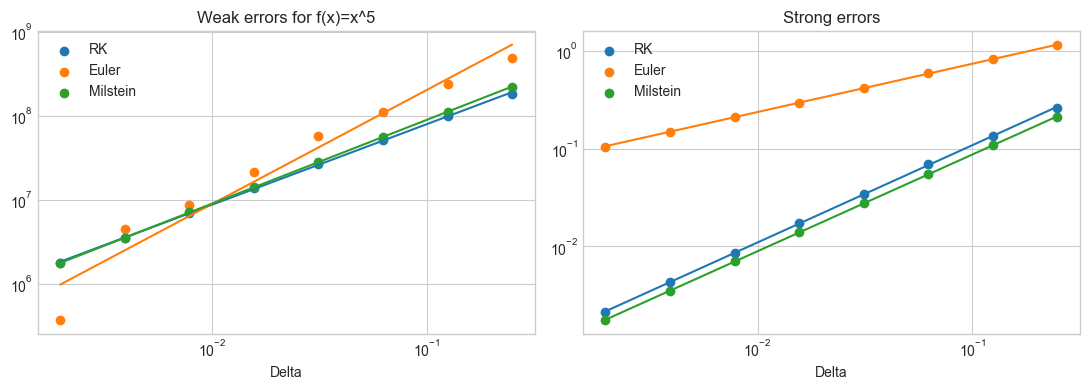

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for name in solvers:
    ax1.scatter(deltas, experimentData[name]["weakError"], label=name)
    ax1.plot(deltas, regFunctions[name]["weakError"](deltas))
ax1.set_title("Weak errors for f(x)=x^5")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Delta")
ax1.legend()

for name in solvers:
    ax2.scatter(deltas, experimentData[name]["strongError"], label=name)
    ax2.plot(deltas, regFunctions[name]["strongError"](deltas))
ax2.set_title("Strong errors")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Delta")
ax2.legend()

plt.tight_layout()
plt.show()


**Комментарий.** Для GBM метод Эйлера обычно показывает сильный порядок около $1/2$, а Мильштейн и стохастический Рунге-Кутта - около $1$ в сильном смысле. Слабые оценки по Монте-Карло шумнее, особенно для функции $x^5$: высокие степени усиливают вклад редких больших значений GBM. Поэтому в выводе важнее порядок величин и наклон на log-log графике, чем точное совпадение регрессионных коэффициентов с теорией на третьем знаке.

## Диффузия Ланжевена

Рассматриваем плотность с точностью до нормировки:
$$
p(x,y)=\exp\left(-\frac{0.8x^2+(y-|x|^{2/3})^2}{4}\right).
$$
Для численной устойчивости около нуля используем сглаженную версию $|x|^{2/3}\approx(x^2+\varepsilon)^{1/3}$.

В лекции для инвариантной плотности, пропорциональной $p$, используется нормировка
$$
dX_t=\nabla\log p(X_t)\,dt+\sqrt2\,dW_t.
$$
Именно такой масштаб шума берём в простом примере ниже. При другом постоянном $\sigma$ стационарная плотность меняется, что полезно для художественных экспериментов, но уже не является точным семплированием из исходной $p$.

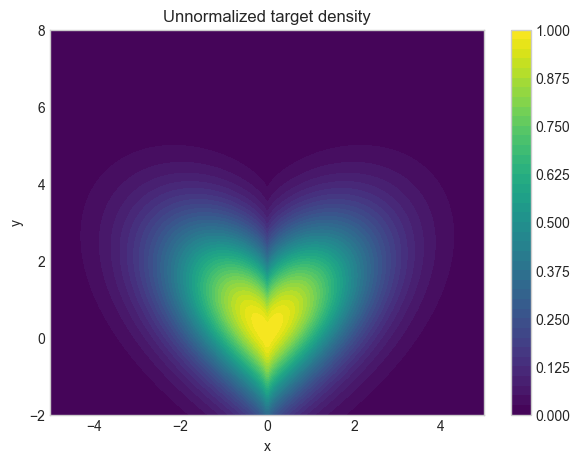

In [6]:
def ridge(x):
    return (x**2 + 1e-6) ** (1 / 3)


def ridge_derivative(x):
    return (2 * x / 3) * (x**2 + 1e-6) ** (-2 / 3)


def coolDensity(x, y):
    return np.exp(-(0.8 * x**2 + (y - ridge(x)) ** 2) / 4)


def bLan(t, x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    a = ridge(x1)
    da = ridge_derivative(x1)
    grad_x = -0.4 * x1 + 0.5 * (x2 - a) * da
    grad_y = -0.5 * (x2 - a)
    return np.column_stack([grad_x, grad_y])


def sigmaLan(t, x):
    n = x.shape[0]
    mats = np.repeat(np.eye(2)[None, :, :], n, axis=0)
    return np.sqrt(2.0) * mats


xs = np.linspace(-5, 5, 250)
ys = np.linspace(-2, 8, 250)
xx, yy = np.meshgrid(xs, ys)
zz = coolDensity(xx, yy)

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title("Unnormalized target density")
im = ax.contourf(xx, yy, zz, levels=40, cmap="viridis")
fig.colorbar(im, ax=ax)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [7]:
a, b = 0.0, 1000.0
Nt = 5000
ts_lan = np.linspace(a, b, Nt + 1)
Ntraj = 500
x0_lan = np.random.uniform([-1, 0], [20, 12], size=(Ntraj, 2))

solver_lan = EulerSolver(bLan, sigmaLan)
apprTrajs = solver_lan.solve(x0_lan, ts_lan)
print(apprTrajs.shape)


(500, 2, 5001)


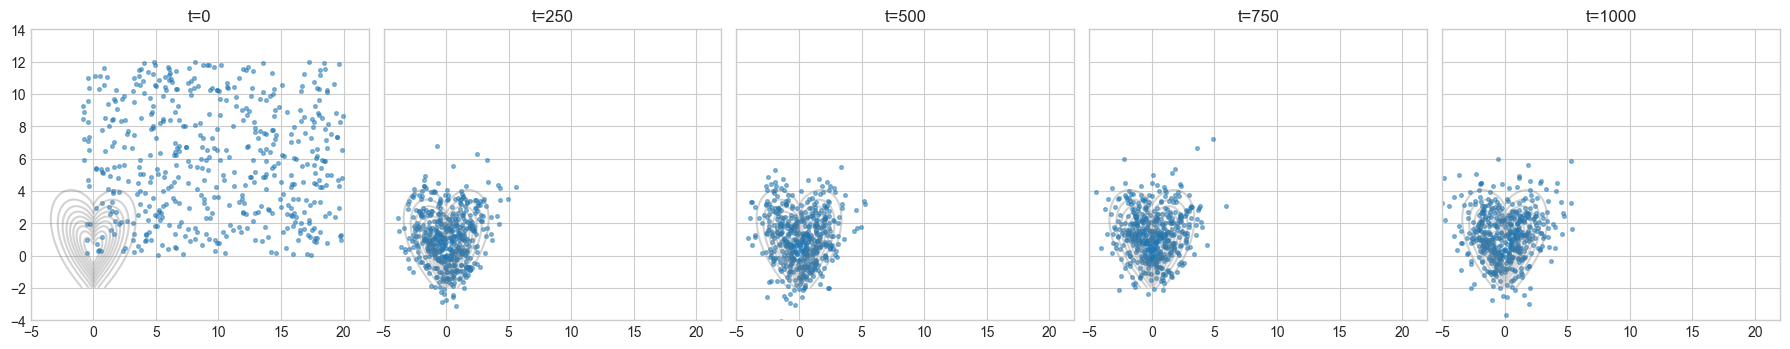

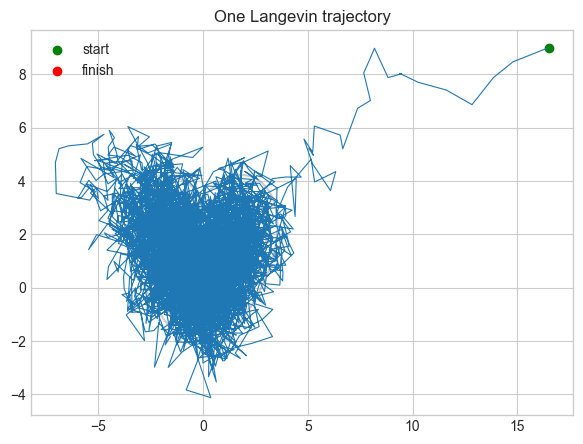

In [8]:
times_to_show = [0, 250, 500, 750, 1000]
ids_to_show = [np.argmin(np.abs(ts_lan - t)) for t in times_to_show]

fig, axes = plt.subplots(1, len(ids_to_show), figsize=(18, 3.6), sharex=True, sharey=True)
for ax, t, idx in zip(axes, times_to_show, ids_to_show):
    ax.set_title(f"t={t}")
    ax.contour(xx, yy, zz, levels=10, colors="gray", alpha=0.35)
    ax.scatter(apprTrajs[:, 0, idx], apprTrajs[:, 1, idx], s=7, alpha=0.5)
    ax.set_xlim(-5, 22)
    ax.set_ylim(-4, 14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title("One Langevin trajectory")
traj_id = 0
ax.contour(xx, yy, zz, levels=15, colors="gray", alpha=0.4)
ax.plot(apprTrajs[traj_id, 0, :], apprTrajs[traj_id, 1, :], lw=0.8)
ax.scatter(apprTrajs[traj_id, 0, 0], apprTrajs[traj_id, 1, 0], c="green", label="start")
ax.scatter(apprTrajs[traj_id, 0, -1], apprTrajs[traj_id, 1, -1], c="red", label="finish")
ax.legend()
plt.show()


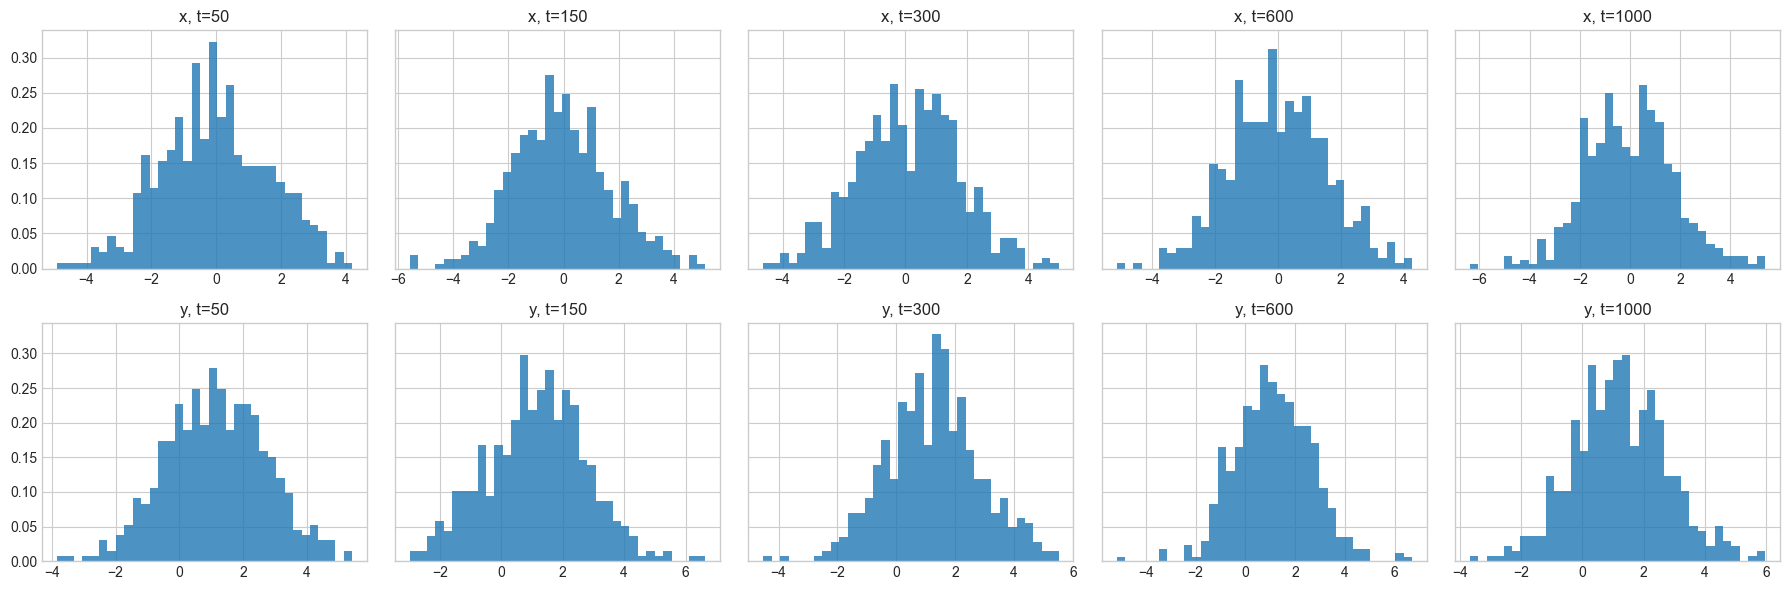

In [9]:
hist_ids = [np.argmin(np.abs(ts_lan - t)) for t in [50, 150, 300, 600, 1000]]

fig, axes = plt.subplots(2, len(hist_ids), figsize=(18, 6), sharey="row")
for col, idx in enumerate(hist_ids):
    axes[0, col].hist(apprTrajs[:, 0, idx], bins=35, density=True, alpha=0.8)
    axes[0, col].set_title(f"x, t={ts_lan[idx]:.0f}")
    axes[1, col].hist(apprTrajs[:, 1, idx], bins=35, density=True, alpha=0.8)
    axes[1, col].set_title(f"y, t={ts_lan[idx]:.0f}")
plt.tight_layout()
plt.show()


По scatter-графикам видно, что начальное равномерное облако постепенно стягивается к области высокой плотности. Гистограммы после примерно $t=300$ меняются заметно меньше, чем в начале, поэтому для этой настройки разумный burn-in находится на масштабе нескольких сотен единиц времени. Точное значение зависит от шага, масштаба шума и начального распределения. Важно помнить лекционный нюанс: ULA с постоянным шагом имеет дискретизационное смещение, поэтому это численная иллюстрация сходимости, а не точный независимый сэмплер.

## Художественный эффект через ULA

Для гауссовской смеси
$$
p(x)=\sum_{i=1}^N\alpha_i\varphi_{\sigma_G}(x-a_i)
$$
градиент логарифма равен
$$
\nabla\log p(x)=
\frac{\sum_i\alpha_i\varphi_{\sigma_G}(x-a_i)\left[-(x-a_i)/\sigma_G^2\right]}
{\sum_i\alpha_i\varphi_{\sigma_G}(x-a_i)}.
$$
То есть это взвешенное среднее направлений к якорям смеси, где веса зависят от текущей точки. В коде ниже параметр `sigma` - это стандартное отклонение гауссовских компонент, поэтому дисперсия компоненты равна `sigma**2`.

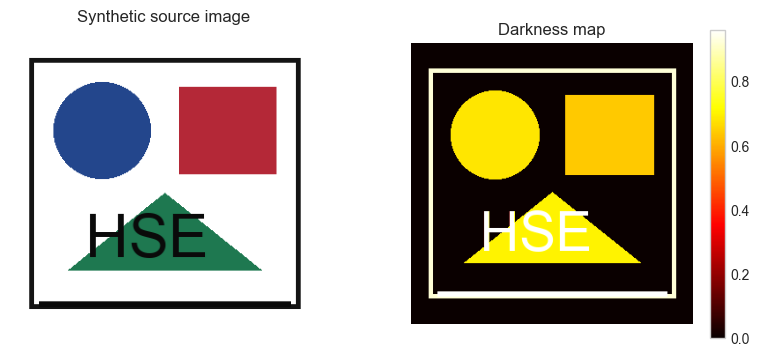

In [10]:
def make_demo_image(size=320):
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    draw.rectangle([20, 30, size - 20, size - 30], outline=(20, 20, 20), width=5)
    draw.ellipse([45, 55, 145, 155], fill=(35, 70, 140))
    draw.rectangle([175, 60, 275, 150], fill=(180, 40, 55))
    draw.polygon([(60, 250), (160, 170), (260, 250)], fill=(30, 120, 80))
    draw.line([30, 285, 290, 285], fill=(10, 10, 10), width=6)
    try:
        font = ImageFont.truetype("Arial.ttf", 62)
    except Exception:
        font = None
    draw.text((78, 180), "HSE", fill=(10, 10, 10), font=font)
    return np.asarray(img).astype(np.uint8)


def image_darkness(img):
    return 1 - np.mean(img, axis=-1) / 255


demo_img = make_demo_image()
darkness = image_darkness(demo_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title("Synthetic source image")
axes[0].imshow(demo_img)
axes[0].axis("off")
axes[1].set_title("Darkness map")
im = axes[1].imshow(darkness, cmap="hot")
fig.colorbar(im, ax=axes[1])
axes[1].axis("off")
plt.show()


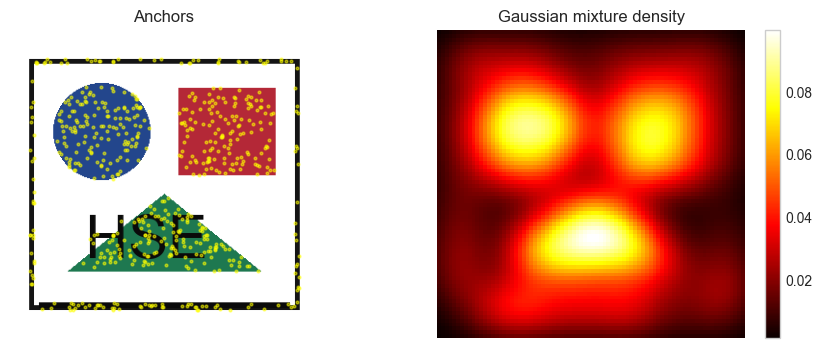

In [11]:
def constructSDE(imgRGB, nAnchors=400, sigma=24.0, sigmaNoise=16.0, darkness=True):
    weights_map = image_darkness(imgRGB) if darkness else np.mean(imgRGB, axis=-1) / 255
    weights = weights_map.reshape(-1)
    weights = np.maximum(weights, 1e-8)
    h, w = weights_map.shape
    yy, xx = np.indices((h, w))
    all_points = np.column_stack([yy.ravel(), xx.ravel()]).astype(float)
    ids = np.random.choice(np.arange(weights.size), size=nAnchors, replace=False, p=weights / weights.sum())
    anchors = all_points[ids]
    anchorWeights = weights[ids]
    anchorWeights = anchorWeights / anchorWeights.sum()
    # sigma is the standard deviation of each isotropic Gaussian component.
    sigma2 = sigma**2

    def stable_weights(x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:
            x = x[None, :]
        diff = x[:, None, :] - anchors[None, :, :]
        log_terms = np.log(anchorWeights[None, :]) - np.sum(diff**2, axis=2) / (2 * sigma2)
        log_terms -= np.max(log_terms, axis=1, keepdims=True)
        ww = np.exp(log_terms)
        ww /= np.sum(ww, axis=1, keepdims=True)
        return ww, diff

    def densGradLog(t, x):
        ww, diff = stable_weights(x)
        return -np.sum(ww[:, :, None] * diff, axis=1) / sigma2

    def noiseSig(t, x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:
            x = x[None, :]
        return sigmaNoise * np.repeat(np.eye(2)[None, :, :], x.shape[0], axis=0)

    def dens(x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:
            x = x[None, :]
        diff = x[:, None, :] - anchors[None, :, :]
        terms = anchorWeights[None, :] * np.exp(-np.sum(diff**2, axis=2) / (2 * sigma2))
        return np.sum(terms, axis=1)

    return dens, densGradLog, noiseSig, (anchors, anchorWeights)


density, bFun, sigFun, (anchors, anchorWeights) = constructSDE(demo_img, nAnchors=600, sigma=24, sigmaNoise=18)

ys = np.arange(0, demo_img.shape[0], 4)
xs = np.arange(0, demo_img.shape[1], 4)
xx_img, yy_img = np.meshgrid(xs, ys)
grid_points = np.column_stack([yy_img.ravel(), xx_img.ravel()])
dens_vals = density(grid_points).reshape(yy_img.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].set_title("Anchors")
axes[0].imshow(demo_img)
axes[0].scatter(anchors[:, 1], anchors[:, 0], s=4, c="yellow", alpha=0.5)
axes[0].axis("off")
axes[1].set_title("Gaussian mixture density")
im = axes[1].imshow(dens_vals, cmap="hot")
fig.colorbar(im, ax=axes[1])
axes[1].axis("off")
plt.show()

In [12]:
def draw_line(canvas, p0, p1, color, width=1):
    y0, x0 = p0
    y1, x1 = p1
    steps = int(max(abs(y1 - y0), abs(x1 - x0))) + 1
    ys = np.linspace(y0, y1, steps).astype(int)
    xs = np.linspace(x0, x1, steps).astype(int)
    h, w = canvas.shape[:2]
    for dy in range(-width, width + 1):
        for dx in range(-width, width + 1):
            yy = np.clip(ys + dy, 0, h - 1)
            xx = np.clip(xs + dx, 0, w - 1)
            canvas[yy, xx] = color


class ULArtist:
    def __init__(self, img, solver):
        self.img = img
        self.solver = solver
        self.imgDims = img.shape[:2]

    def genNewPixelULA(self, loc, t, delta):
        new_pixel = self.solver.step(np.asarray(loc, dtype=float)[None, :], t, t + delta)[0]
        h, w = self.imgDims
        return np.array([np.clip(new_pixel[0], 0, h - 1), np.clip(new_pixel[1], 0, w - 1)])

    def sampleInitialPoint(self):
        h, w = self.imgDims
        return np.array([np.random.uniform(0, h - 1), np.random.uniform(0, w - 1)])

    def ulaTransformer(self, initialPoint, nIterations, delta):
        pts = np.zeros((nIterations + 1, 2), dtype=float)
        pts[0] = initialPoint
        for i in range(nIterations):
            pts[i + 1] = self.genNewPixelULA(pts[i], i * delta, delta)
        return pts

    def drawImage(self, nIterations, delta=0.03, Ntrajs=1, takeEvery=1, lineWidth=0, fixedPointColor=None):
        canvas = np.ones_like(self.img) * 255
        all_points = []
        for _ in range(Ntrajs):
            pts = self.ulaTransformer(self.sampleInitialPoint(), nIterations, delta)
            pts_int = np.rint(pts[::takeEvery]).astype(int)
            all_points.append(pts_int)
            for i in range(len(pts_int) - 1):
                y, x = pts_int[i]
                color = np.array(fixedPointColor if fixedPointColor is not None else self.img[y, x], dtype=np.uint8)
                if lineWidth > 0:
                    draw_line(canvas, pts_int[i], pts_int[i + 1], color, width=lineWidth)
                else:
                    canvas[y, x] = color
        return canvas, all_points


artist = ULArtist(demo_img, EulerSolver(bFun, sigFun))


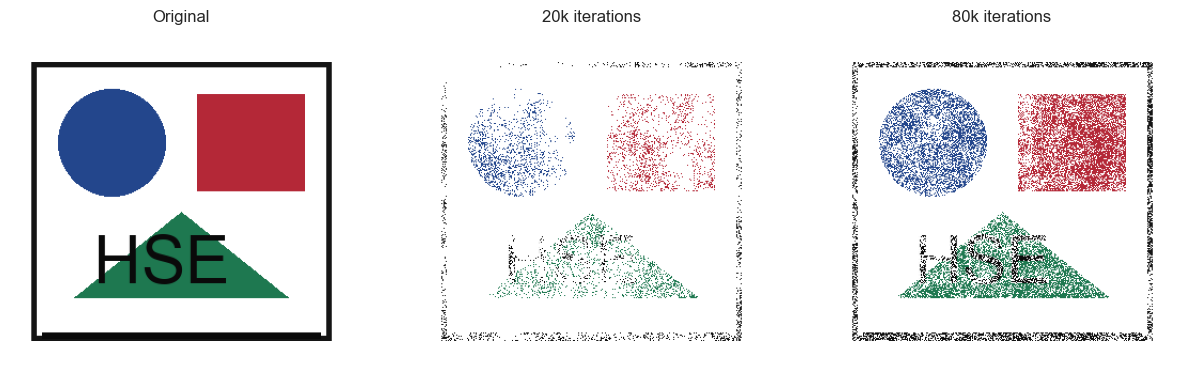

Saved: hw3_outputs/ula_20k_demo.png and hw3_outputs/ula_80k_demo.png


In [13]:
small_img, small_pts = artist.drawImage(nIterations=20_000, delta=0.03, Ntrajs=2, takeEvery=2, lineWidth=0)
large_img, large_pts = artist.drawImage(nIterations=80_000, delta=0.03, Ntrajs=2, takeEvery=2, lineWidth=0)

output_dir = Path("hw3_outputs")
output_dir.mkdir(exist_ok=True)
Image.fromarray(small_img).save(output_dir / "ula_20k_demo.png")
Image.fromarray(large_img).save(output_dir / "ula_80k_demo.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("Original")
axes[0].imshow(demo_img)
axes[1].set_title("20k iterations")
axes[1].imshow(small_img)
axes[2].set_title("80k iterations")
axes[2].imshow(large_img)
for ax in axes:
    ax.axis("off")
plt.show()

print("Saved:", output_dir / "ula_20k_demo.png", "and", output_dir / "ula_80k_demo.png")

При малом числе итераций видны отдельные случайные штрихи; при большем числе итераций изображение становится плотнее и лучше проявляет области высокой плотности смеси. В исходном задании предлагается `500000` итераций; код выше поддерживает этот режим, но в чистовом ноутбуке выполнен укороченный вариант, чтобы файл быстро пересчитывался. Для сдачи с большим лимитом времени достаточно увеличить `nIterations` в той же ячейке.

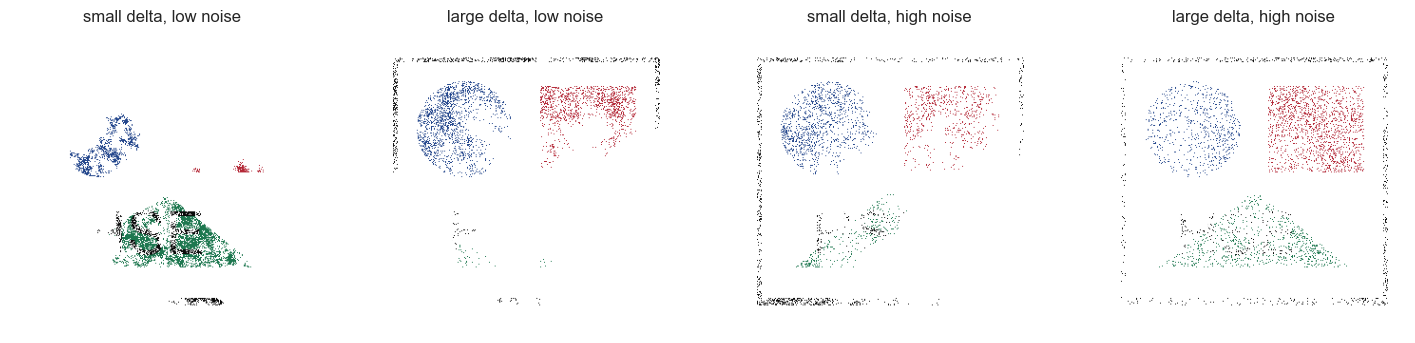

In [14]:
variants = [
    ("small delta, low noise", 0.015, 10),
    ("large delta, low noise", 0.08, 10),
    ("small delta, high noise", 0.015, 28),
    ("large delta, high noise", 0.08, 28),
]

fig, axes = plt.subplots(1, len(variants), figsize=(18, 4))
for ax, (title, delta_v, noise_v) in zip(axes, variants):
    _, b_tmp, sig_tmp, _ = constructSDE(demo_img, nAnchors=500, sigma=24, sigmaNoise=noise_v)
    art_tmp = ULArtist(demo_img, EulerSolver(b_tmp, sig_tmp))
    img_tmp, _ = art_tmp.drawImage(nIterations=25_000, delta=delta_v, Ntrajs=1, takeEvery=2)
    ax.set_title(title)
    ax.imshow(img_tmp)
    ax.axis("off")
plt.show()


Большой шаг делает траектории резче и менее устойчивыми: процесс чаще перескакивает через локальные области плотности. Большая дисперсия шума размывает рисунок и увеличивает исследование пространства. Малый шум и малый шаг дают более аккуратные линии, но процесс медленнее обходит разные области.


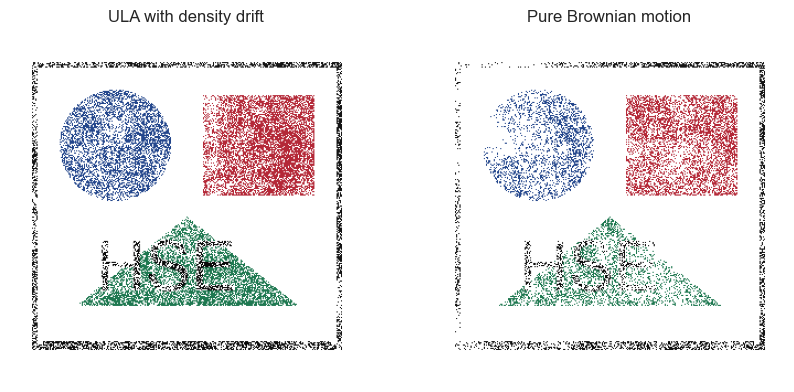

In [15]:
def zeroDrift(t, x):
    return np.zeros_like(x)


def brownianNoise(t, x):
    return 18 * np.repeat(np.eye(2)[None, :, :], x.shape[0], axis=0)


brownian_artist = ULArtist(demo_img, EulerSolver(zeroDrift, brownianNoise))
brownian_img, _ = brownian_artist.drawImage(nIterations=50_000, delta=0.03, Ntrajs=2, takeEvery=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].set_title("ULA with density drift")
axes[0].imshow(large_img)
axes[1].set_title("Pure Brownian motion")
axes[1].imshow(brownian_img)
for ax in axes:
    ax.axis("off")
plt.show()


Отличие от обычного Винеровского процесса в наличии дрейфа $\nabla\log p(x)$. ULA тянет частицу к областям высокой плотности, поэтому рисунок концентрируется около темных/важных зон изображения. Чистый Винеровский процесс не видит картинку и рисует почти бесструктурное случайное покрытие.


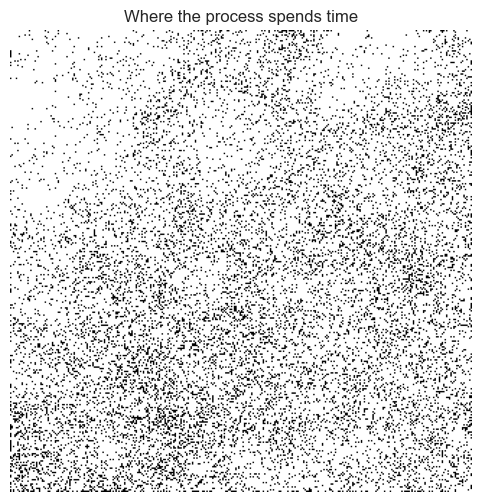

Saved: hw3_outputs/ula_visit_map_demo.png


In [16]:
long_points_img, long_points = artist.drawImage(
    nIterations=120_000,
    delta=0.03,
    Ntrajs=1,
    takeEvery=8,
    lineWidth=0,
    fixedPointColor=(0, 0, 0),
)

Image.fromarray(long_points_img).save(output_dir / "ula_visit_map_demo.png")

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Where the process spends time")
ax.imshow(long_points_img)
ax.axis("off")
plt.show()

print("Saved:", output_dir / "ula_visit_map_demo.png")

Если после burn-in рисовать только точки одним цветом, получается эмпирическая карта посещаемости. При очень большом числе шагов (`2e7` в условии) она должна приближать стационарную плотность ULA: точки сгущаются там, где гауссовская смесь имеет большие значения. В ноутбуке выполнена более короткая версия, а параметры `nIterations`, `takeEvery` и `fixedPointColor` уже вынесены так, чтобы тот же код можно было масштабировать.
